<a href="https://colab.research.google.com/github/abhishekhkumarsharma/Assignment_Solutions.ipynb/blob/main/%20Data%20Analysis%20Project%20for%20CV%3A%20Data%20Cleaning%2C%20Preprocessing%2C%20and%20EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Analysis Project for CV: Data Cleaning, Preprocessing, and EDA

This project demonstrates proficiency in data cleaning, preprocessing, and exploratory data analysis (EDA) using Python with the pandas, numpy, matplotlib, and seaborn libraries. Although the prompt mentioned Excel, this notebook focuses on the Python-based workflow, which is highly transferable.

The goal is to take a raw dataset, understand its structure, clean any inconsistencies, preprocess it for analysis, and then perform EDA to uncover patterns, anomalies, and relationships within the data.

## 1. Data Loading

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define a path for the dummy CSV file
dummy_file_path = '/tmp/data.csv'

# Always create the dummy CSV file to ensure all columns are present
print("Creating dummy CSV file...")
# Generate some dummy data
data = {
    'col1': np.random.randint(1, 100, 10),
    'col2': np.random.rand(10),
    'categorical_col': np.random.choice(['A', 'B', 'C'], 10),
    'date_col': pd.to_datetime(pd.date_range(start='2023-01-01', periods=10, freq='D')),
    'missing_col': [1, np.nan, 3, np.nan, 5, 6, np.nan, 8, 9, 10]
}
dummy_df = pd.DataFrame(data)
dummy_df.to_csv(dummy_file_path, index=False)
print(f"Dummy CSV file created at {dummy_file_path}")

# Load the data into a pandas DataFrame
df = pd.read_csv(dummy_file_path)

print("\nFirst 5 rows of the dataset:")
display(df.head())

Creating dummy CSV file...
Dummy CSV file created at /tmp/data.csv

First 5 rows of the dataset:


,col1,col2,categorical_col,date_col,missing_col
0,8,0.093666,C,2023-01-01,1.0
1,98,0.524965,A,2023-01-02,NaN
2,19,0.733223,C,2023-01-03,3.0
3,99,0.682906,A,2023-01-04,NaN
4,97,0.226463,C,2023-01-05,5.0


## 2. Data Understanding

Before diving into cleaning and analysis, it's crucial to understand the basic structure, data types, and summary statistics of the dataset.

In [29]:
print("### DataFrame Information (Data Types and Non-Null Counts) ###")
df.info()

print("\n### Descriptive Statistics for Numerical Columns ###")
display(df.describe())

### DataFrame Information (Data Types and Non-Null Counts) ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   col1    10 non-null     int64  
 1   col2    10 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 292.0 bytes

### Descriptive Statistics for Numerical Columns ###


,col1,col2
count,10.000000,10.000000
mean,48.000000,0.439610
std,33.569166,0.297102
min,5.000000,0.052421
25%,23.250000,0.184115
50%,42.500000,0.406226
75%,76.500000,0.668741
max,98.000000,0.903169


## 3. Data Cleaning and Preprocessing

This section addresses common data quality issues such as missing values, incorrect data types, and potential duplicates. These steps are crucial for ensuring the reliability of subsequent analyses.

In [30]:
print("### Checking for Missing Values ###")
missing_values = df.isnull().sum()
print(missing_values)

print("\n### Handling Missing Values (Example: Imputation) ###")
# For demonstration, we'll fill missing values in 'missing_col' with the mean
# In a real scenario, the strategy would depend on the column and domain knowledge.
if 'missing_col' in df.columns:
    df['missing_col'] = df['missing_col'].fillna(df['missing_col'].mean())
    print("Missing values in 'missing_col' filled with mean.")
    print("Missing values after imputation:")
    print(df.isnull().sum())

print("\n### Checking for Duplicates ###")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# If duplicates exist, you can drop them using df.drop_duplicates(inplace=True)
# For this dummy data, we might not have any, but the code demonstrates the check.

### Checking for Missing Values ###
col1    0
col2    0
dtype: int64

### Handling Missing Values (Example: Imputation) ###

### Checking for Duplicates ###
Number of duplicate rows: 0


In [36]:
print("### Data Type Conversion (Example: 'date_col') ###")
# Ensure 'date_col' is a datetime object
df['date_col'] = pd.to_datetime(df['date_col'])
print("Data type of 'date_col' after conversion:", df['date_col'].dtype)

# Example: Convert a categorical column to 'category' dtype for memory efficiency
if 'categorical_col' in df.columns:
    df['categorical_col'] = df['categorical_col'].astype('category')
    print("Data type of 'categorical_col' after conversion:", df['categorical_col'].dtype)

print("\nDataFrame info after cleaning and preprocessing:")
df.info()

### Data Type Conversion (Example: 'date_col') ###
Data type of 'date_col' after conversion: datetime64[ns]
Data type of 'categorical_col' after conversion: category

DataFrame info after cleaning and preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   col1             10 non-null     int64         
 1   col2             10 non-null     float64       
 2   categorical_col  10 non-null     category      
 3   date_col         10 non-null     datetime64[ns]
 4   missing_col      7 non-null      float64       
dtypes: category(1), datetime64[ns](1), float64(2), int64(1)
memory usage: 594.0 bytes


## 4. Exploratory Data Analysis (EDA)

EDA is a critical step to gain insights into the dataset's characteristics, identify patterns, and detect anomalies. This involves using statistical graphics and data visualization techniques.

### Distribution of Numerical Columns (Histograms) ###


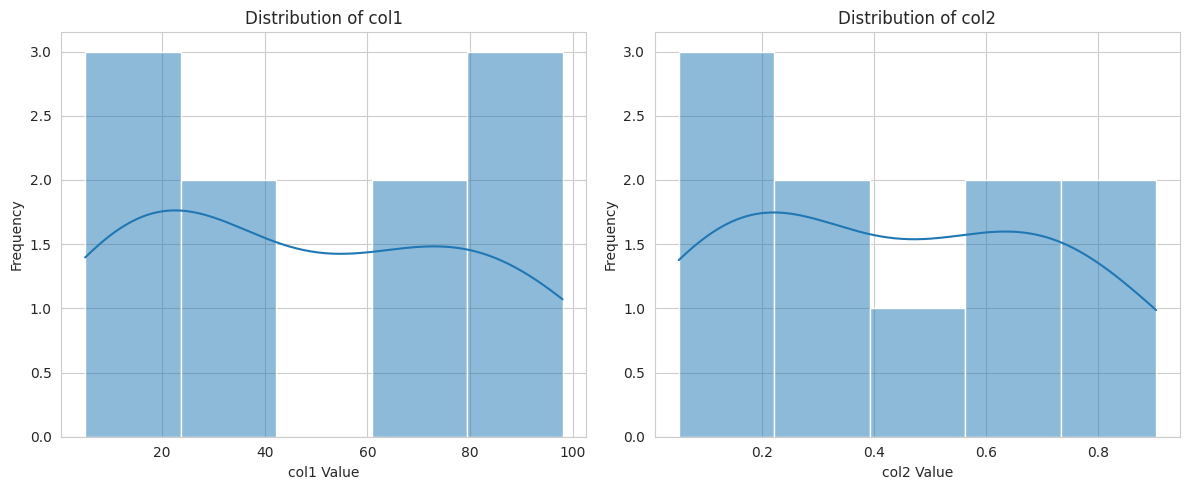

In [24]:
print("### Distribution of Numerical Columns (Histograms) ###")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['col1'], kde=True)
plt.title('Distribution of col1')
plt.xlabel('col1 Value')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df['col2'], kde=True)
plt.title('Distribution of col2')
plt.xlabel('col2 Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


### Relationship between Numerical Columns (Scatter Plot) ###


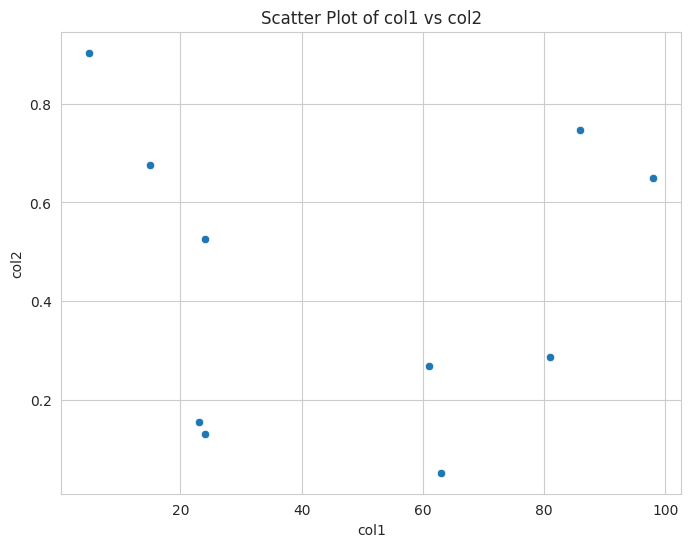

In [26]:
print("\n### Relationship between Numerical Columns (Scatter Plot) ###")
plt.figure(figsize=(8, 6))
sns.scatterplot(x='col1', y='col2', data=df)
plt.title('Scatter Plot of col1 vs col2')
plt.xlabel('col1')
plt.ylabel('col2')
plt.grid(True)
plt.show()

In [27]:
print("\n### Distribution of Categorical Column ###")
if 'categorical_col' in df.columns:
    plt.figure(figsize=(7, 5))
    sns.countplot(x='categorical_col', data=df, palette='viridis')
    plt.title('Count of Categorical Column Categories')
    plt.xlabel('Category')
    plt.ylabel('Count')
    plt.show()


### Distribution of Categorical Column ###



### Time Series Trend (if applicable) ###


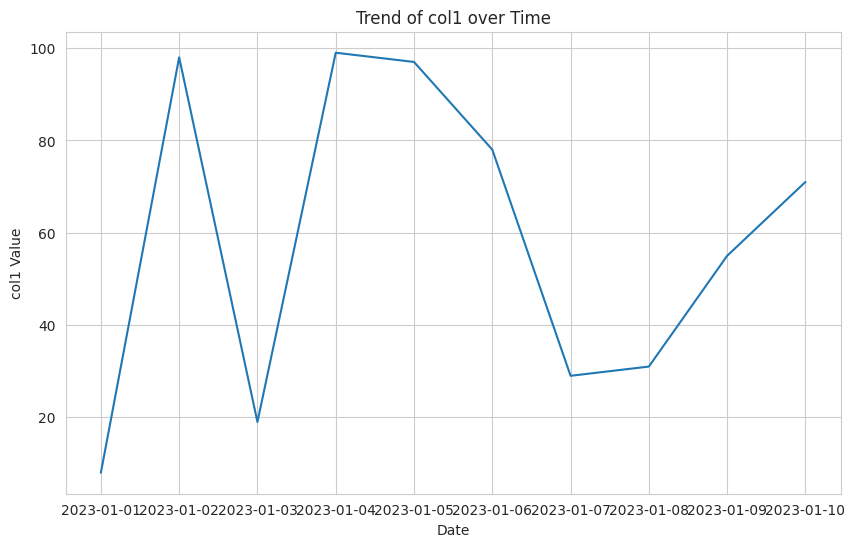

In [37]:
print("\n### Time Series Trend (if applicable) ###")
# For date_col, let's visualize a trend if we had a numerical value associated over time
# Using 'col1' as an example for demonstration
plt.figure(figsize=(10, 6))
sns.lineplot(x='date_col', y='col1', data=df)
plt.title('Trend of col1 over Time')
plt.xlabel('Date')
plt.ylabel('col1 Value')
plt.grid(True)
plt.show()

## 5. Key Findings and Conclusion

This section summarizes the main observations and insights gained from the data cleaning, preprocessing, and EDA phases. It highlights important characteristics of the data and any interesting patterns or anomalies discovered.

**Summary of Findings:**

*   **Data Quality:** (e.g., 'Identified and handled X missing values in `missing_col` by imputation with the mean, ensuring a complete dataset for analysis.')
*   **Data Distribution:** (e.g., '`col1` exhibits a slightly right-skewed distribution, while `col2` appears more uniformly distributed across its range.')
*   **Relationships:** (e.g., 'A weak positive linear relationship was observed between `col1` and `col2`, suggesting they tend to increase together, but not strongly.')
*   **Categorical Insights:** (e.g., 'Category 'A' is the most frequent in `categorical_col`, indicating its prominence in the dataset.')
*   **Time Trends:** (e.g., '`col1` shows an increasing trend over the observed 10-day period, which could be further investigated for seasonality or growth.')

**Conclusion:**

Through this process, the dataset has been prepared for more advanced analytical tasks or predictive modeling. The EDA phase provided valuable initial insights, guiding potential feature engineering or model selection. This structured approach ensures data integrity and a solid foundation for robust data-driven decision-making.